In [60]:
#1. Load --> Data, Model
#2. Preprocess
#3. Split ( Train, Test)
#4. Design and Implement out model. 
#5. Train
#6. Evaluate
#7. Predict

In [61]:
import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers

In [62]:
#load 
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [63]:
train_images.shape

(60000, 28, 28)

In [64]:
test_images.shape

(10000, 28, 28)

In [65]:
train_labels.shape

(60000,)

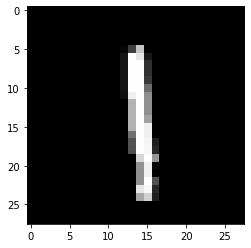

In [66]:
plt.imshow(train_images[8], cmap='gray')

In [67]:
train_labels[8]

1

In [68]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [69]:
train_labels[8]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [70]:
train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0

In [71]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

In [84]:
#Data generation
datagen = ImageDataGenerator(rotation_range=45) 
# Image30 --> Randomly(-45, 45) --> apply(Image30)
datagen.fit(train_images)

In [83]:
# number of generated image ? 

In [18]:
from  keras.models import Sequential
from keras.layers import Dense

In [86]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax') 
])

In [87]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [88]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [90]:
hist = model.fit(datagen.flow(train_images, train_labels, batch_size=32), epochs=20, validation_data=(test_images, test_labels), callbacks=[early_stop])

Epoch 1/20
1875/1875 [==============================] - 21s 11ms/step - loss: 0.9307 - accuracy: 0.7038 - val_loss: 0.3108 - val_accuracy: 0.9021
Epoch 2/20
1875/1875 [==============================] - 21s 11ms/step - loss: 0.6103 - accuracy: 0.8104 - val_loss: 0.2379 - val_accuracy: 0.9211
Epoch 3/20
1875/1875 [==============================] - 18s 10ms/step - loss: 0.5403 - accuracy: 0.8358 - val_loss: 0.2055 - val_accuracy: 0.9342
Epoch 4/20
1875/1875 [==============================] - 19s 10ms/step - loss: 0.4972 - accuracy: 0.8497 - val_loss: 0.1927 - val_accuracy: 0.9380
Epoch 5/20
1875/1875 [==============================] - 19s 10ms/step - loss: 0.4670 - accuracy: 0.8603 - val_loss: 0.1780 - val_accuracy: 0.9430
Epoch 6/20
1875/1875 [==============================] - 19s 10ms/step - loss: 0.4536 - accuracy: 0.8634 - val_loss: 0.1699 - val_accuracy: 0.9460
Epoch 7/20
1875/1875 [==============================] - 18s 10ms/step - loss: 0.4319 - accuracy: 0.8706 - val_loss: 0.1706 -

In [91]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [92]:
hist.history['loss']

[0.9306835532188416,
 0.6103122234344482,
 0.5402665138244629,
 0.4972092807292938,
 0.4669860601425171,
 0.4535689651966095,
 0.43192747235298157,
 0.4191545248031616,
 0.4142407476902008,
 0.40341344475746155,
 0.38740575313568115,
 0.3898674249649048,
 0.3791908621788025,
 0.3755876421928406,
 0.3715282678604126,
 0.3604494035243988,
 0.3644773066043854,
 0.3578570783138275,
 0.35651546716690063,
 0.3538064658641815]

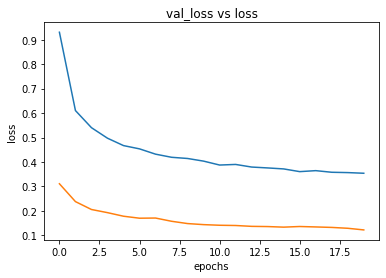

In [93]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('val_loss vs loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()